In [2]:
import pandas as pd
df = pd.read_csv("/Users/hiteshallakki/Documents/datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.count()

customerID          7043
gender              7043
SeniorCitizen       7043
Partner             7043
Dependents          7043
tenure              7043
PhoneService        7043
MultipleLines       7043
InternetService     7043
OnlineSecurity      7043
OnlineBackup        7043
DeviceProtection    7043
TechSupport         7043
StreamingTV         7043
StreamingMovies     7043
Contract            7043
PaperlessBilling    7043
PaymentMethod       7043
MonthlyCharges      7043
TotalCharges        7043
Churn               7043
dtype: int64

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
g = df.groupby("Contract")[["Churn"]].count()

### Feature engineering 

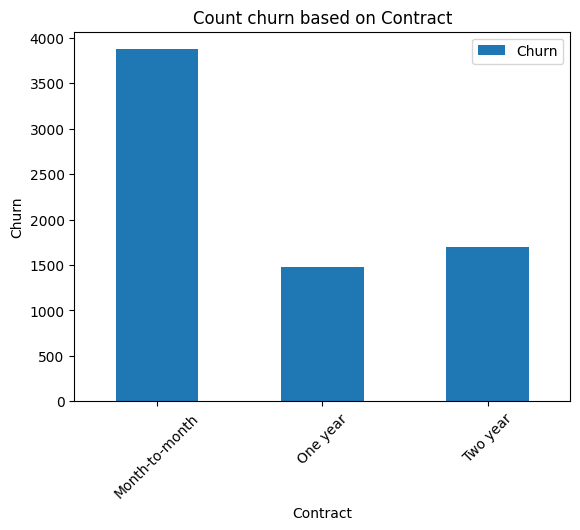

In [7]:
import matplotlib.pyplot as plt
ax = g.plot(kind = "bar")

ax.set_title("Count churn based on Contract")
ax.set_xlabel('Contract')
ax.set_ylabel('Churn')

plt.xticks(rotation=45)
plt.show()

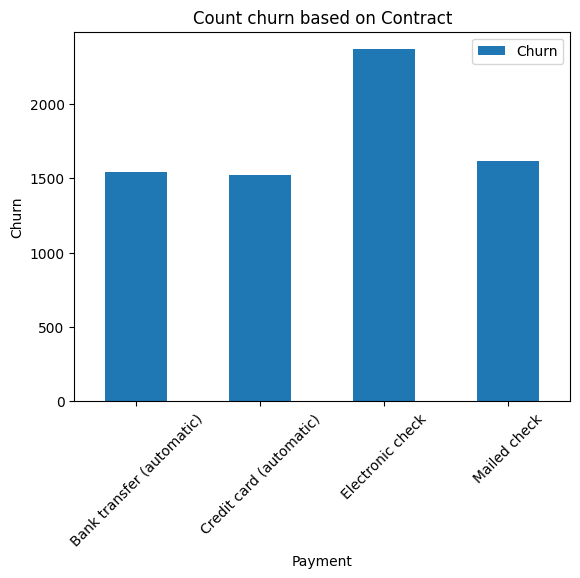

In [8]:
g = df.groupby("PaymentMethod")[["Churn"]].count()
import matplotlib.pyplot as plt
ax = g.plot(kind = "bar")

ax.set_title("Count churn based on Contract")
ax.set_xlabel('Payment')
ax.set_ylabel('Churn')

plt.xticks(rotation=45)
plt.show()

From the above analysis we understood that Month-month Contracts and electronic check are most categories took the hit

### Calculating the churn rate and its monthly/Annual revenue?

In [9]:
churn_rate = df["Churn"].value_counts(normalize = True)['Yes'] * 100
round(churn_rate,2)

np.float64(26.54)

In [10]:
#revenue impact
avg_monthly_charges = df[df['Churn'] == 'Yes']['MonthlyCharges'].mean()
total_churned_customers = df[df['Churn'] == 'Yes'].shape[0]

Monthy_impact = avg_monthly_charges * total_churned_customers
Annualimpact = Monthy_impact* 12

print(format(Monthy_impact),'monthyimpact')
print(format(round(Annualimpact,2)),'Annualimpact')


139130.85 monthyimpact
1669570.2 Annualimpact


It costs 5–10x more to acquire a new customer than to retain one — so how much are we losing by not acting on churn early?

In [11]:
CAC_low =  avg_monthly_charges * 5
CAC_high = avg_monthly_charges * 10

cost_to_replace_low = total_churned_customers * CAC_low
cost_to_replace_high = total_churned_customers * CAC_high

print(f"Cost to replace churned customers: ${cost_to_replace_low:,.0f} — ${cost_to_replace_high:,.0f}")

Cost to replace churned customers: $695,654 — $1,391,308


Which customer segments are most valuable and most at risk simultaneously?

In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'] , errors = 'coerce')

In [13]:
df['MonthlyCharges'].describe()


count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

In [14]:
df['TotalCharges'].describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

Defining High value customers

In [15]:
threshold = df['TotalCharges'].quantile(0.75)

df['ValueSegment'] = df['TotalCharges'].apply(lambda x: 'High Value' if x>= threshold else 'Low Value')

In [16]:
df[['TotalCharges','ValueSegment']]

,TotalCharges,ValueSegment
0,29.85,Low Value
1,1889.50,Low Value
2,108.15,Low Value
3,1840.75,Low Value
4,151.65,Low Value
...,...,...
7038,1990.50,Low Value
7039,7362.90,High Value
7040,346.45,Low Value
7041,306.60,Low Value


In [17]:
df['ValueSegment'].value_counts()

ValueSegment
Low Value     5285
High Value    1758
Name: count, dtype: int64

Comparing values with churn

In [18]:
pd.crosstab(df['ValueSegment'],df['Churn'])

Churn,No,Yes
ValueSegment,,
High Value,1503,255
Low Value,3671,1614


In [19]:
pd.crosstab(df['ValueSegment'],df['Churn'],normalize = 'index')*100

Churn,No,Yes
ValueSegment,,
High Value,85.494881,14.505119
Low Value,69.460738,30.539262


Identify high Value Customers who Churn

In [20]:
high_value_churn = df[(df['ValueSegment'] == 'High Value') & (df['Churn'] == 'Yes')]

In [21]:
high_value_churn.shape

(255, 22)

In [22]:
high_value_churn['Contract'].value_counts()

Contract
Month-to-month    129
One year           88
Two year           38
Name: count, dtype: int64

In [23]:
high_value_churn['InternetService'].value_counts()

InternetService
Fiber optic    241
DSL             14
Name: count, dtype: int64

In [24]:
high_value_churn['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             130
Bank transfer (automatic)     65
Credit card (automatic)       53
Mailed check                   7
Name: count, dtype: int64

In [25]:
high_value_churn['TechSupport'].value_counts()

TechSupport
No     167
Yes     88
Name: count, dtype: int64

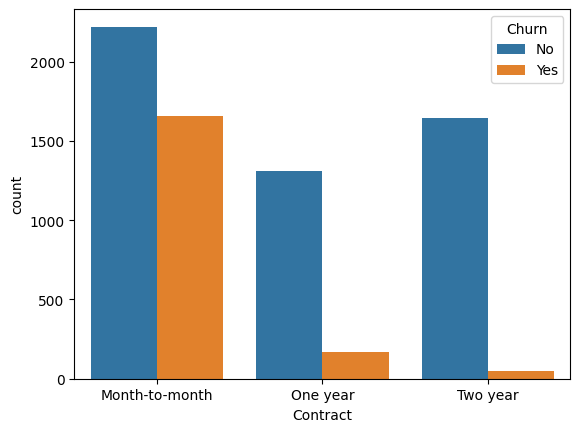

In [26]:
import seaborn as sns

sns.countplot(data=df, x='Contract', hue='Churn')
plt.show()

### Customers Who churn no matter what you do

In [27]:
df['tenure_group'] = pd.cut(df['tenure'],bins = [0,6,12,24,48,72],labels=['0-6 months','6-12 months','12-24 months','24-48 months','48+ months'])
df['tenure_group']      

0         0-6 months
1       24-48 months
2         0-6 months
3       24-48 months
4         0-6 months
            ...     
7038    12-24 months
7039      48+ months
7040     6-12 months
7041      0-6 months
7042      48+ months
Name: tenure_group, Length: 7043, dtype: category
Categories (5, object): ['0-6 months' < '6-12 months' < '12-24 months' < '24-48 months' < '48+ months']

In [28]:
#calculating churn rate
churn_rate = pd.crosstab(df['tenure_group'],df['Churn'],normalize = 'index')
churn_rate*100

Churn,No,Yes
tenure_group,,
0-6 months,46.666667,53.333333
6-12 months,64.113475,35.886525
12-24 months,71.289062,28.710938
24-48 months,79.611041,20.388959
48+ months,90.486824,9.513176


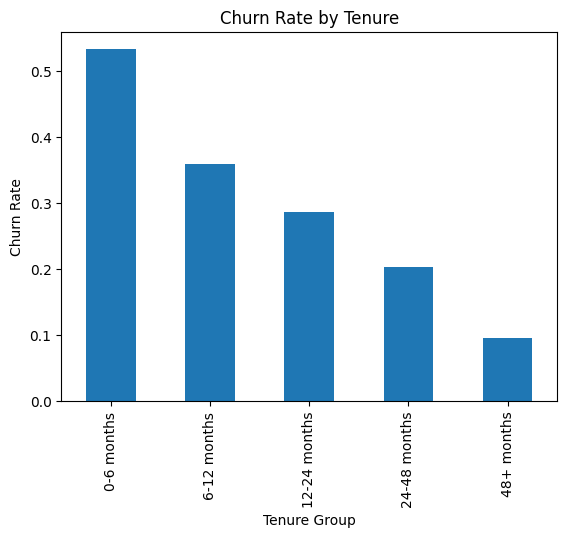

In [29]:
churn_rate['Yes'].plot(kind = 'bar')

plt.ylabel("Churn Rate")
plt.xlabel("Tenure Group")
plt.title("Churn Rate by Tenure")
plt.show()

Combining with the contract type and month - to month to know the churn rate 

In [30]:
pd.crosstab(
    [df['tenure_group'],df['Contract']],
    df['Churn'],
    normalize = 'index'
)

Churn                              No       Yes
tenure_group Contract                          
0-6 months   Month-to-month  0.447983  0.552017
             One year        0.894737  0.105263
             Two year        1.000000  0.000000
6-12 months  Month-to-month  0.580034  0.419966
             One year        0.894118  0.105882
             Two year        1.000000  0.000000
12-24 months Month-to-month  0.622795  0.377205
             One year        0.918782  0.081218
             Two year        1.000000  0.000000
24-48 months Month-to-month  0.670823  0.329177
             One year        0.893822  0.106178
             Two year        0.978102  0.021898
48+ months   Month-to-month  0.739766  0.260234
             One year        0.870662  0.129338
             Two year        0.966746  0.033254

Risk Matrix

In [31]:
df['risk_segment'] = df['Churn'].apply(lambda x: 'High Risk' if x == 'Yes' else 'Low Risk')

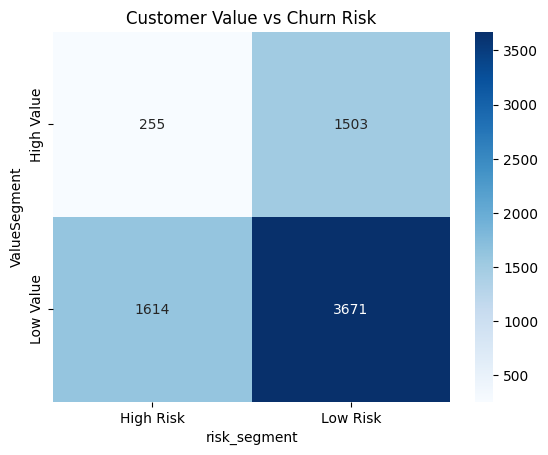

In [32]:
import seaborn as sns

matrix = pd.crosstab(df['ValueSegment'], df['risk_segment'])

sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Customer Value vs Churn Risk")
plt.show()

### Data Modeling

In [33]:
df['Churn'] = df['Churn'].map({'No':0 ,'Yes': 1})

In [34]:
y = df['Churn']

In [35]:
X = df.drop(['customerID','Churn', 'TotalCharges', 'tenure_group', 'ValueSegment', 'risk_segment'],axis =1)

one hot encoding on categorical variables 

In [36]:
X = pd.get_dummies(X,drop_first = True )

Train Test Split

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### Baseline model Logistic Regression

In [86]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter = 1000)
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [87]:
from sklearn.metrics import classification_report
pred_lr= model.predict(X_test)
print(classification_report(y_test,pred_lr))

              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.69      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



In [40]:
from sklearn.metrics import roc_auc_score

prob = model.predict_proba(X_test)[:,1]

roc_auc_score(y_test, prob)

np.float64(0.860699794010786)

In [42]:
probs = model.predict_proba(X_test)[:,1]
probs

array([0.62356023, 0.09348115, 0.00922611, ..., 0.05455221, 0.02245478,
       0.44425634])

In [88]:
pred_30 = (probs > 0.3).astype(int)
print(classification_report(y_test,pred_30))

              precision    recall  f1-score   support

           0       0.91      0.77      0.84      1036
           1       0.56      0.79      0.65       373

    accuracy                           0.78      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.78      0.79      1409



In [46]:
import numpy as np
from sklearn.metrics import classification_report

thresholds = [0.5, 0.4, 0.3, 0.2]

for t in thresholds:
    preds = (probs > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, preds))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.69      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      1036
           1       0.60      0.67      0.64       373

    accuracy                           0.80      1409
   macro avg       0.74      0.76      0.75      1409
weighted avg       0.80      0.80      0.80      1409


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.91      0.77      0.84      1036
           1       0.56      0.79      0.65       373

    accuracy                           0.78      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82   

In [47]:
pred_30 = (probs > 0.4).astype(int)
print(classification_report(y_test,pred_30))

              precision    recall  f1-score   support

           0       0.88      0.84      0.86      1036
           1       0.60      0.67      0.64       373

    accuracy                           0.80      1409
   macro avg       0.74      0.76      0.75      1409
weighted avg       0.80      0.80      0.80      1409



### Finding the best threshold 

In [48]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, probs)

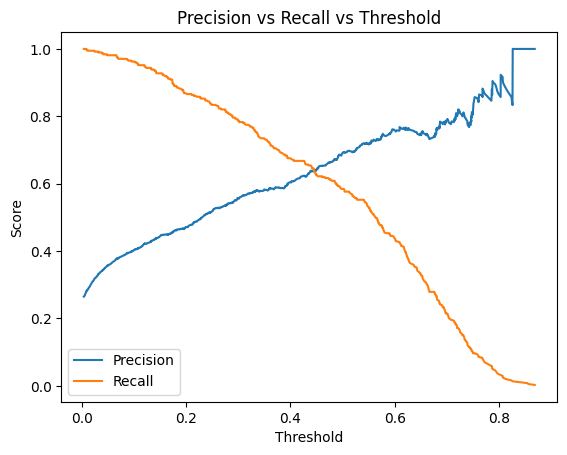

In [49]:
import matplotlib.pyplot as plt

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall vs Threshold")
plt.legend()

plt.show()

In [50]:
import numpy as np

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)
print("Precision:", precision[best_index])
print("Recall:", recall[best_index])
print("F1 Score:", f1_scores[best_index])

Best Threshold: 0.3192565703350501
Precision: 0.5711462450592886
Recall: 0.774798927613941
F1 Score: 0.6575649266920608


In [51]:
pred_30 = (probs > 0.3192565703350501).astype(int)
print(classification_report(y_test,pred_30))

              precision    recall  f1-score   support

           0       0.91      0.79      0.84      1036
           1       0.57      0.77      0.66       373

    accuracy                           0.79      1409
   macro avg       0.74      0.78      0.75      1409
weighted avg       0.82      0.79      0.79      1409



### Decision Tree

In [71]:
from sklearn.tree import DecisionTreeClassifier


dt = DecisionTreeClassifier(
    max_depth=6,            
    class_weight='balanced',# handling  imbalance
    random_state=42
)

In [72]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=42)

In [82]:
probs_dt = dt.predict_proba(X_test)[:,1]


pred_dt = (probs_dt > 0.3192565703350501).astype(int)

In [83]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred_dt))

              precision    recall  f1-score   support

           0       0.95      0.57      0.71      1036
           1       0.43      0.92      0.59       373

    accuracy                           0.66      1409
   macro avg       0.69      0.74      0.65      1409
weighted avg       0.81      0.66      0.68      1409



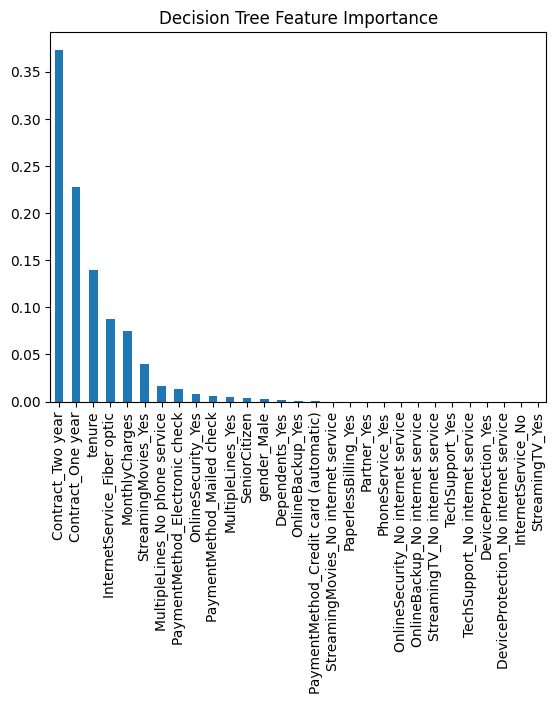

In [84]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(dt.feature_importances_, index=X_train.columns)
feature_importance.sort_values(ascending=False).plot(kind='bar')
plt.title("Decision Tree Feature Importance")
plt.show()

### Random Forest

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators = 200,
    max_depth = 6,
    class_weight ='balanced',
    random_state = 42
)
rf.fit(X_train,y_train)

probs_rf = rf.predict_proba(X_test)[:,1]
pred_rf = (probs_rf >0.3192565703350501).astype(int)

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.96      0.52      0.68      1036
           1       0.42      0.94      0.58       373

    accuracy                           0.63      1409
   macro avg       0.69      0.73      0.63      1409
weighted avg       0.82      0.63      0.65      1409



### RF LightGBM

In [60]:



lgb = LGBMClassifier(class_weight='balanced')

lgb.fit(X_train, y_train)

probs_lgb = lgb.predict_proba(X_test)[:,1]
pred_lgb = (probs_lgb > 0.3192565703350501).astype(int)

print(classification_report(y_test, pred_lgb))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1496, number of negative: 4138
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000405 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 382
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
              precision    recall  f1-score   support

           0       0.93      0.63      0.75      1036
           1       0.46      0.87      0.60       373

    accuracy                           0.69      1409
   macro avg       0.69      0.75      0.68      1409
weighted avg       0.80      0.69      0.71      1409



### RF trying data on SMOTE

In [61]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

model_sm = LogisticRegression(max_iter=1000, class_weight='balanced')
model_sm.fit(X_train_sm, y_train_sm)

probs_sm = model_sm.predict_proba(X_test)[:,1]
pred_sm = (probs_sm > 0.3192565703350501).astype(int)

print(classification_report(y_test, pred_sm))

/Users/hiteshallakki/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.92      0.66      0.77      1036
           1       0.47      0.84      0.60       373

    accuracy                           0.71      1409
   macro avg       0.70      0.75      0.69      1409
weighted avg       0.80      0.71      0.73      1409



### Hyper Parameter Tuning ,using GridSearchCV with XGBoost

In [62]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report

In [63]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',   # default for classification
    use_label_encoder=False,
    scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train)  # handles imbalance
)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 1],
    'colsample_bytree': [0.7, 1]
}

In [64]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='recall',   # optimize recall for churn
    cv=skf,
    verbose=2,
    n_jobs=-1
)

In [65]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


/Users/hiteshallakki/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [15:09:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/hiteshallakki/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [15:09:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/hiteshallakki/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [15:09:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/hiteshallakki/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [15:09:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are no

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importanc...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 1],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200],
                         'subsample': [0.7, 1]},
             scoring='recall', verbose=2)

In [66]:
best_xgb = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1}


In [70]:
probs_xgb = best_xgb.predict_proba(X_test)[:,1]

# Use threshold tuned before, e.g., 0.3
pred_xgb = (probs_xgb > 0.5).astype(int)

print(classification_report(y_test, pred_xgb))

              precision    recall  f1-score   support

           0       0.94      0.69      0.79      1036
           1       0.50      0.87      0.64       373

    accuracy                           0.74      1409
   macro avg       0.72      0.78      0.72      1409
weighted avg       0.82      0.74      0.75      1409



###

In [85]:


# Store predictions from models you already trained
# pred_lr, pred_dt, pred_rf, pred_xgb (if available)
# y_test is the true labels

def get_metrics(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        "Precision (Churn)": report['1']['precision'],
        "Recall (Churn)": report['1']['recall'],
        "F1 (Churn)": report['1']['f1-score'],
    }

# Create dictionary of results
results = {
    "Logistic Regression": get_metrics(y_test, pred_lr),
    "Decision Tree": get_metrics(y_test, pred_dt),
    "Random Forest": get_metrics(y_test, pred_rf),
}

# Add XGBoost if you trained it
if 'pred_xgb' in globals():
    results["XGBoost"] = get_metrics(y_test, pred_xgb)

# Convert to DataFrame for a clean table
df_results = pd.DataFrame(results).T
df_results = df_results.sort_values("Recall (Churn)", ascending=False)

# Print the summary table
print(df_results)

                     Precision (Churn)  Recall (Churn)  F1 (Churn)
Random Forest                 0.415584        0.943700    0.577049
Decision Tree                 0.433628        0.919571    0.589347
XGBoost                       0.502326        0.868633    0.636542
Logistic Regression           0.692063        0.584450    0.633721
